# Exploratory Data Analaysis
## PyOd Outlier Detection

In [2]:
# Imports
import sys, os
sys.path.insert(0, '../src')
from skrub import TableReport
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scikit_na as na
from pathlib import Path
import importlib
import preprocess
import explore
from preprocess import PRE_EXCLUDED


In [3]:
# Load datasets
df_im, df_cl = explore.load_data()

In [5]:
# Pre-Process
df_cl_vis = preprocess.clean_cl(df_cl, False)
df_im_vis = preprocess.clean_im(df_im, False)
df_im_vis = df_im_vis[~df_im_vis['Patient'].isin(PRE_EXCLUDED)]

id_cols = ['Patient', 'Timepoint','Date']



#### Identifying outliers with PyOD, using functions developed by Zryan Mustafa (https://gitlab.com/zryan.rz/master_outlier_detection_h23)

### Imputing Immunological Dataset

In [4]:
# Drop columns with >25% NaN before imputation
df_im_mod = preprocess.remove_nan_cols(df_im_vis, threshold=0.25)

# Iterative imputation:
df_im_imputed, _ = preprocess.impute_iterative(df_im_mod, ex_cols=id_cols, iterations=20, verbose=False)

# Median imputation
df_im_median = preprocess.impute_median(
    df_im_mod,
    ex_cols=id_cols, verbose=False)

  Dropped 14 columns with >25% NaN: ['TC_CD25hi', 'B_CD25hi', 'Eos_HLADR+', 'Mo2_HLADRhi', 'TC_HLADRhi', 'NK_HLADRhi', 'Eos_CD69+', 'Bas_CD69+', 'Mo_CD69+', 'B_CD69+', 'DC_CD69+', 'TH naive_PD1+', 'TH eff_PD1+', 'TC naive_PD1+']


## Outlier Detection - Iterative Imputed dataset:


PyOD Outlier Detection for Immunological - Iterative Imputation dataset
Running GEC to select 6 most dissimilar algorithms...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


GEC selected: ['QMCD', 'IForest', 'LODA', 'HBOS', 'ECOD', 'COPOD']
Ensemble: 6 algorithms, contamination=0.05
Running visualiser_OD...
loo


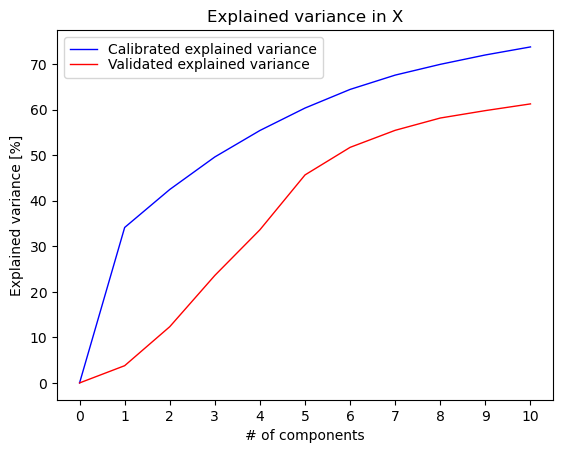

45 [-0.80287221 -0.896037  ]
96 [0.46848712 0.78160438]
104 [-0.04403142  0.34519312]
122 [-0.54730385  0.06627036]
62 [-0.86419991  0.58939617]
96 [0.14689506 0.09274561]


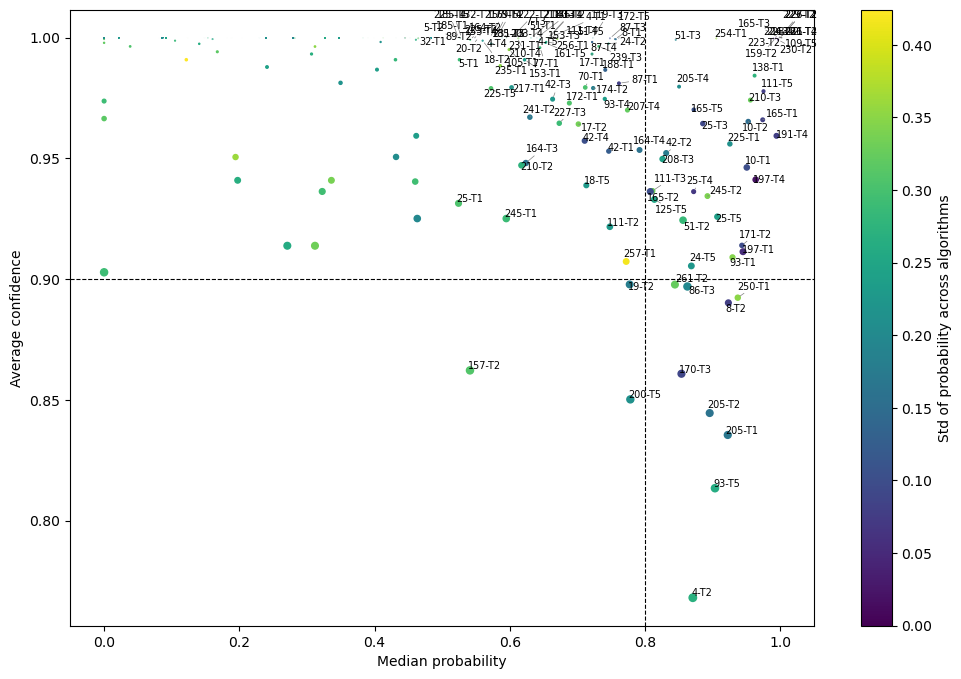


=== Outlier Detection Summary — Immunological - Iterative Imputation (contamination=0.05) ===
Flagged by >= 1 algorithm: 86
Flagged by >= 3 algorithms: 34
Flagged by >= 6 algorithms: 11

=== Top Upper-right Quadrant (median prob. > 0.9 & avg conf. > 0.9) — Immunological - Iterative Imputation ===
Total: 27
        No. OD Detected  Median_Probability  Avg_Confidence
221-T2                5            1.000000        1.000000
163-T1                6            1.000000        1.000000
109-T5                6            0.999999        1.000000
266-T4                6            0.999995        1.000000
226-T2                6            0.999789        1.000000
227-T2                6            0.999469        1.000000
229-T2                5            0.998720        1.000000
228-T2                6            0.998662        1.000000
224-T2                6            0.998188        0.999998
165-T3                6            0.997773        1.000000
230-T2                5        

In [5]:
im_feat_cols = [c for c in df_im_mod.columns if c not in id_cols]

no_od_df_im, outlier_candidates_im = explore.run_pyod_zryan(
    df_im_imputed,
    feature_cols=im_feat_cols,
    contamination=0.05,
    name='Immunological - Iterative Imputation',
)


## Outlier Detection - Median Imputed Dataset:


PyOD Outlier Detection for Immunological - Median Imputed dataset
Running GEC to select 6 most dissimilar algorithms...
GEC selected: ['QMCD', 'HBOS', 'ECOD', 'LODA', 'COPOD', 'KNN']
Ensemble: 6 algorithms, contamination=0.05
Running visualiser_OD...
loo


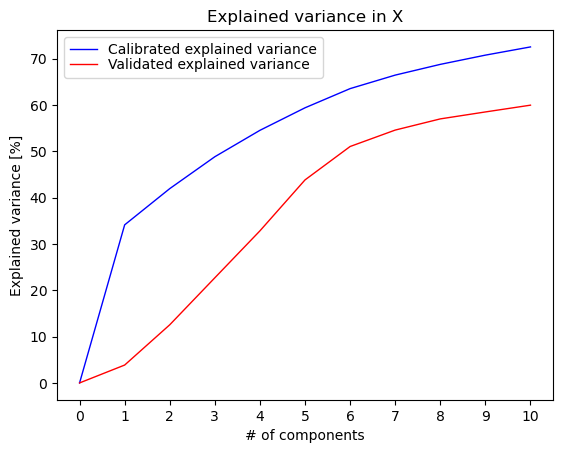

55 [0.55787337 0.34009911]
82 [-0.13547056  0.46165695]
108 [ 0.69301248 -0.48954428]
43 [-0.07795063  0.70902347]
108 [0.92762319 0.23992755]
43 [0.91554374 0.549829  ]
108 [0.34047977 0.60943292]


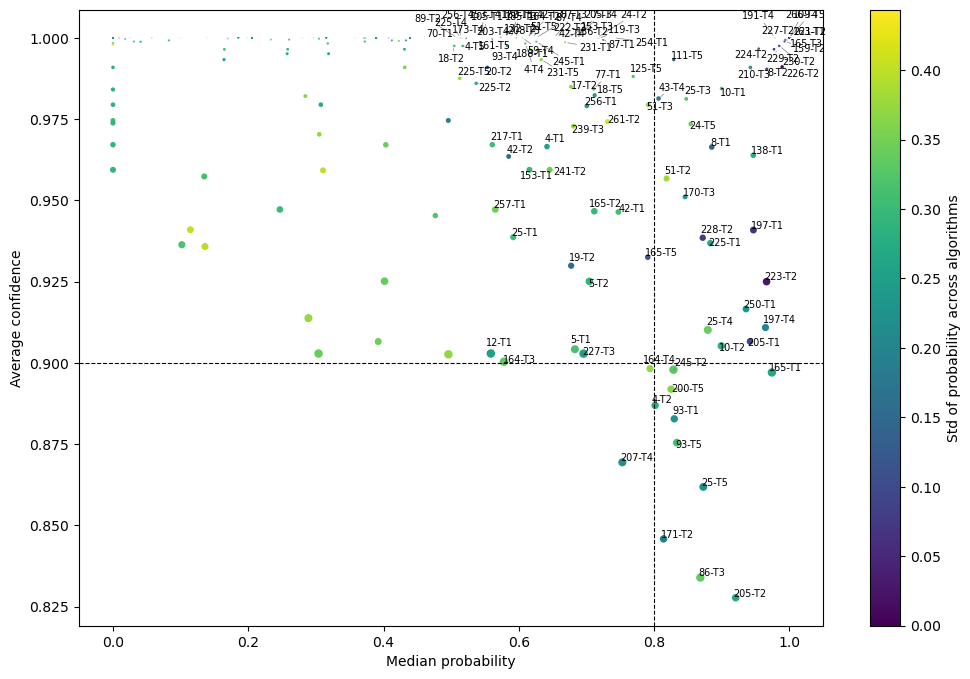


=== Outlier Detection Summary — Immunological - Median Imputed (contamination=0.05) ===
Flagged by >= 1 algorithm: 95
Flagged by >= 3 algorithms: 31
Flagged by >= 6 algorithms: 10

=== Top Upper-right Quadrant (median prob. > 0.9 & avg conf. > 0.9) — Immunological - Median Imputed ===
Total: 20
        No. OD Detected  Median_Probability  Avg_Confidence
221-T2                5            1.000000        1.000000
163-T1                6            1.000000        1.000000
109-T5                6            1.000000        1.000000
266-T4                6            0.999989        1.000000
227-T2                6            0.997054        1.000000
165-T3                6            0.994091        0.999392
159-T2                6            0.992854        0.998831
226-T2                6            0.989340        0.991037
230-T2                4            0.985076        0.997482
191-T4                6            0.978696        0.999971
229-T2                5            0.977332

In [6]:

no_od_df_im_med, outlier_candidates_im_med = explore.run_pyod_zryan(
    df_im_median,
    feature_cols=im_feat_cols,
    contamination=0.05,
    name='Immunological - Median Imputed',
)


## Examining Outlier-Features Statistics

In [ ]:
# Calculating Z-Scores of the Outliers Immunological Features
from scipy import stats

im_feat_cols = [c for c in df_im_vis.columns if c not in id_cols]
outliers = [
    (221, 2), (163, 1), (109, 5), (266, 4), (226, 2),
    (227, 2), (229, 2), (228, 2), (224, 2), (165, 3),
    (230, 2), (191, 4), (159, 2), (223, 2), (111, 5),
    (165, 1), (197, 4), (138, 1), (210, 3), (10, 2)]

# Z-scores for all rows (preserving original index)
z_scores = df_im_vis[im_feat_cols].apply(stats.zscore, nan_policy='omit')

# Filter to outlier rows
outlier_mask = pd.Series(False, index=df_im_vis.index)
for pat, tp in outliers:
    outlier_mask |= (df_im_vis['Patient'] == pat) & (df_im_vis['Timepoint'] == tp)

outlier_rows = df_im_vis[outlier_mask]

# For each outlier: show features with |z| > 3, sorted by magnitude
THRESHOLD = 3.0

# Sort outlier rows by number of extreme features (descending)
extreme_counts = {
    orig_idx: (z_scores.loc[orig_idx].abs() > THRESHOLD).sum()
    for orig_idx in outlier_rows.index
}
sorted_indices = sorted(extreme_counts, key=lambda i: extreme_counts[i], reverse=True)

for orig_idx in sorted_indices:
    patient_row = outlier_rows.loc[orig_idx]
    label   = f"P{int(patient_row.Patient)}_T{int(patient_row.Timepoint)}"
    zrow    = z_scores.loc[orig_idx]
    extreme = zrow[zrow.abs() > THRESHOLD].abs().sort_values(ascending=False)

    print(f"\n{'='*50}")
    print(f"{label}  —  {len(extreme)} extreme features (|z| > {THRESHOLD}):")
    for feat, _ in extreme.items():
        z         = zrow[feat]
        val       = patient_row[feat]
        col_mean  = df_im_vis[feat].mean()
        direction = "HIGH" if z > 0 else "LOW"
        print(f"  {feat:<35}  z ={z:+6.2f}     value = {val:<12.5g}mean = {col_mean:<6.4g}   [{direction}]")



P221_T2  —  34 extreme features (|z| > 3.0):
  lymphocytes                          z =+26.94     value = 1.5526e+05  mean = 2024     [HIGH]
  TH                                   z =+26.88     value = 79601       mean = 997      [HIGH]
  T cells                              z =+26.87     value = 1.2054e+05  mean = 1536     [HIGH]
  Eosinophils                          z =+26.84     value = 19230       mean = 222.1    [HIGH]
  NK2                                  z =+26.82     value = 1006.3      mean = 11.8     [HIGH]
  B cells                              z =+26.78     value = 14123       mean = 200      [HIGH]
  NK cells                             z =+26.70     value = 20595       mean = 287.8    [HIGH]
  T8hi                                 z =+26.70     value = 35046       mean = 410.7    [HIGH]
  NK1                                  z =+26.68     value = 18310       mean = 249.7    [HIGH]
  NK_CD8+                              z =+26.66     value = 8723.2      mean = 109.6    [

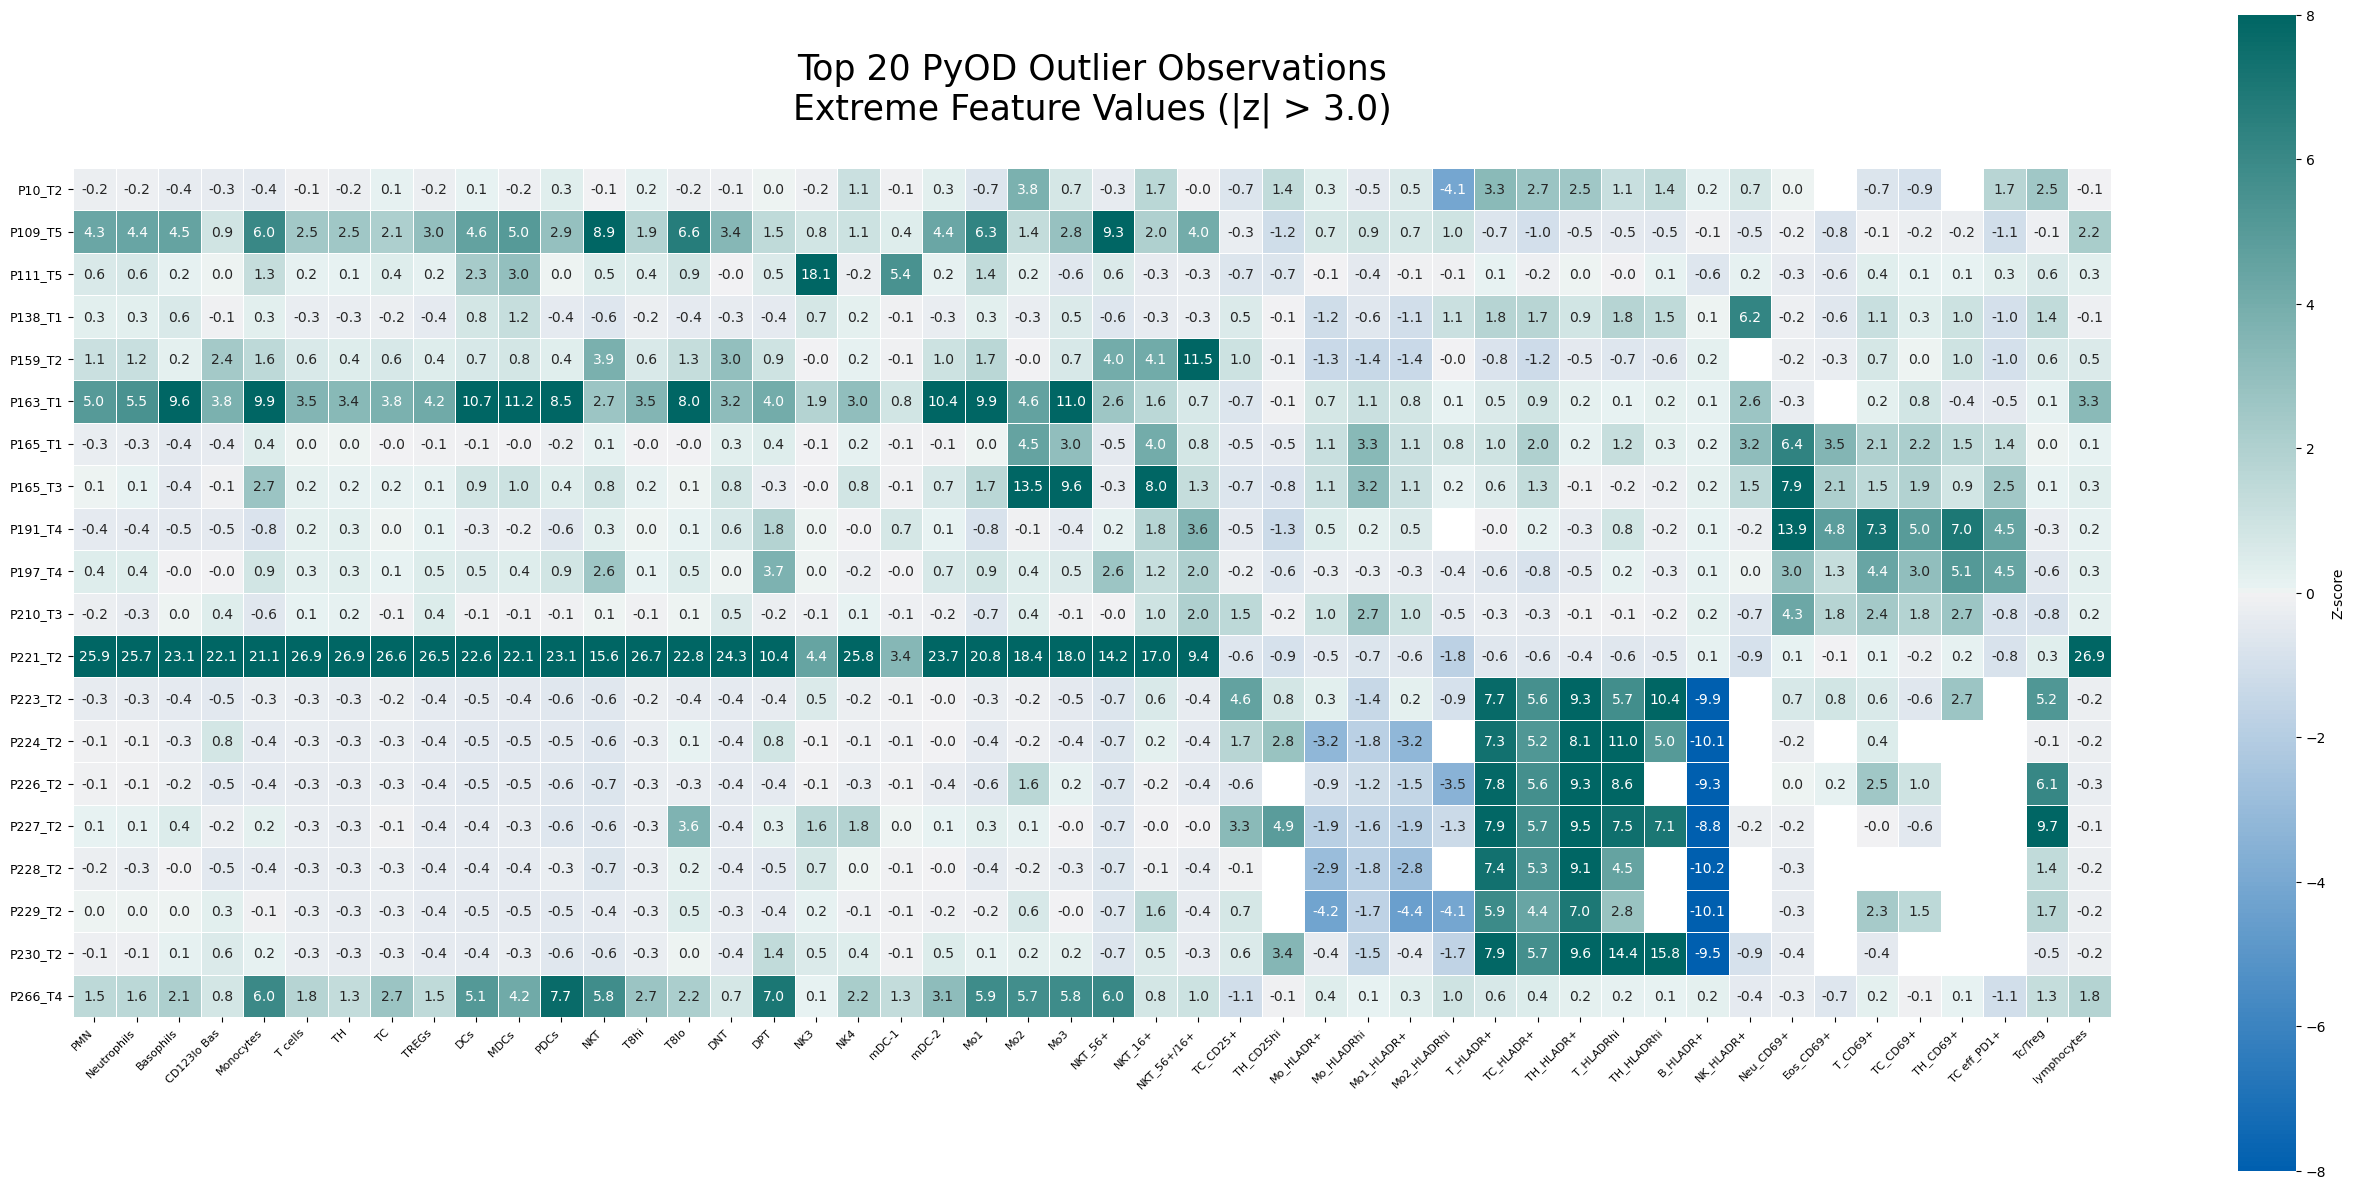

In [17]:
# labelled z-score matrix for the outlier rows
z_outlier_rows = pd.DataFrame(
    {f"P{int(r.Patient)}_T{int(r.Timepoint)}": z_scores.loc[idx]
     for idx, r in outlier_rows.iterrows()}
).T  # patients as rows, features as columns

col_counts    = (z_outlier_rows.abs() > THRESHOLD).sum(axis=0)
extreme_cols  = col_counts[col_counts >= 2].index.tolist() # plotting columns with at least 2 or more outliers.
z_plot        = z_outlier_rows[extreme_cols]

# Square cells: same size per row and column
cell_size = 0.55
fig, ax = plt.subplots(figsize=(len(extreme_cols) * cell_size, len(outlier_rows) * cell_size + 1))
cmap = sns.diverging_palette(240, 190, s=200, l=35, as_cmap=True)


sns.heatmap(
    z_plot,
    cmap=cmap,
    center=0,
    vmin=-8, vmax=8,
    annot=True, fmt='.1f',
    linewidths=0.4,
    square=True,       
    cbar_kws={'label': 'Z-score'},
    ax=ax
)
ax.set_title(f'Top 20 PyOD Outlier Observations\nExtreme Feature Values (|z| > {THRESHOLD})\n', 
             fontsize=25)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()